[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/simple-graph.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58238187-lesson-2-simple-graph)

# The Simplest Graph

Let's build a simple graph with 3 nodes and one conditional edge. 

![Screenshot 2024-08-20 at 3.11.22 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dba5f465f6e9a2482ad935_simple-graph1.png)

In [1]:
%%capture --no-stderr
# %pip install --quiet -U langgraph

## State

First, define the [State](https://docs.langchain.com/oss/python/langgraph/graph-api#state) of the graph. 

The State schema serves as the input schema for all Nodes and Edges in the graph.

Let's use the `TypedDict` class from python's `typing` module as our schema, which provides type hints for the keys.

In [2]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str

## Nodes

[Nodes](https://docs.langchain.com/oss/python/langgraph/graph-api/#nodes) are just python functions.

The first positional argument is the state, as defined above.

Because the state is a `TypedDict` with schema as defined above, each node can access the key, `graph_state`, with `state['graph_state']`.

Each node returns a new value of the state key `graph_state`.
  
By default, the new value returned by each node [will override](https://docs.langchain.com/oss/python/langgraph/graph-api/#reducers) the prior state value.

In [3]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

## Edges

[Edges](https://docs.langchain.com/oss/python/langgraph/graph-api/#edges) connect the nodes.

Normal Edges are used if you want to *always* go from, for example, `node_1` to `node_2`.

[Conditional Edges](https://docs.langchain.com/oss/python/langgraph/graph-api/#conditional-edges) are used if you want to *optionally* route between nodes.
 
Conditional edges are implemented as functions that return the next node to visit based on some logic.

In [4]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    
    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state'] 
    
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"
    
    # 50% of the time, we return Node 3
    return "node_3"

## Graph Construction

Now, we build the graph from our components defined above.

The [StateGraph class](https://docs.langchain.com/oss/python/langgraph/graph-api/#stategraph) is the graph class that we can use.
 
First, we initialize a StateGraph with the `State` class we defined above.
 
Then, we add our nodes and edges.

We use the  [`START` Node, a special node](https://docs.langchain.com/oss/python/langgraph/graph-api/#start-node) that sends user input to the graph, to indicate where to start our graph.
 
The [`END` Node](https://docs.langchain.com/oss/python/langgraph/graph-api/#end-node) is a special node that represents a terminal node. 

Finally, we [compile our graph](https://docs.langchain.com/oss/python/langgraph/graph-api/#compiling-your-graph) to perform a few basic checks on the graph structure. 

We can visualize the graph as a [Mermaid diagram](https://github.com/mermaid-js/mermaid).

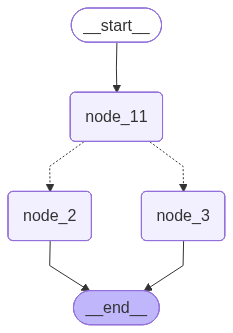

In [5]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build graph
builder = StateGraph(State)
builder.add_node("node_11", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_11")
builder.add_conditional_edges("node_11", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

## Graph Invocation

The compiled graph implements the [runnable](https://reference.langchain.com/python/langchain_core/runnables/?h=runnables) protocol.

This provides a standard way to execute LangChain components. 
 
`invoke` is one of the standard methods in this interface.

The input is a dictionary `{"graph_state": "Hi, this is lance."}`, which sets the initial value for our graph state dict.

When `invoke` is called, the graph starts execution from the `START` node.

It progresses through the defined nodes (`node_1`, `node_2`, `node_3`) in order.

The conditional edge will traverse from node `1` to node `2` or `3` using a 50/50 decision rule. 

Each node function receives the current state and returns a new value, which overrides the graph state.

The execution continues until it reaches the `END` node.

In [6]:
graph.invoke({"graph_state" : "Hi, this is Lance."})

---Node 1---
---Node 3---


{'graph_state': 'Hi, this is Lance. I am sad!'}

`invoke` runs the entire graph synchronously.

This waits for each step to complete before moving to the next.

It returns the final state of the graph after all nodes have executed.

In this case, it returns the state after `node_3` has completed: 

```
{'graph_state': 'Hi, this is Lance. I am sad!'}
```

## AK code

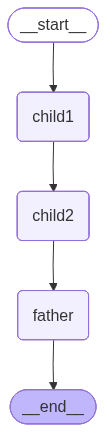

In [12]:
# Random Number Graph with Parity Check

import random
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

# Define the state to hold our numbers and parity results
class RandomState(TypedDict):
    child1_number: int
    child2_number: int
    parity_result: str

# Node 1: First child picks a random number < 100
def child1(state):
    print("--- Child 1 ---")
    num = random.randint(1, 99)  # Random number less than 100
    print(f"Child 1 picked: {num}")
    return {"child1_number": num}

# Node 2: Second child picks a random number < 2 * (first child's number)
def child2(state):
    print("--- Child 2 ---")
    max_num = 2 * state['child1_number']
    num = random.randint(1, max_num - 1)  # Random number less than 2*child1_number
    print(f"Child 2 picked: {num} (max allowed: {max_num - 1})")
    return {"child2_number": num}

# Node 3: Father finds odd/even parity of both numbers
def father(state):
    print("--- Father ---")
    num1 = state['child1_number']
    num2 = state['child2_number']
    
    # parity1 = "odd" if num1 % 2 != 0 else "even"
    # parity2 = "odd" if num2 % 2 != 0 else "even"
    # result = f"Child 1 number ({num1}) is {parity1}, Child 2 number ({num2}) is {parity2}"

    # Construct a prompt for the LLM
    prompt = (
        f"The first number is {num1}. The second number is {num2}. "
        "For each number, state whether it is 'odd' or 'even'. "
        "Return the result in this format: 'Child 1 number (N1) is [parity], Child 2 number (N2) is [parity]'"
    )

    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

    response = llm.invoke(prompt)
    result = response.content.strip()

    print(f"Father determined (using LLM): {result}")
    
    return {"parity_result": result}

# Build the graph
builder = StateGraph(RandomState)
builder.add_node("child1", child1)
builder.add_node("child2", child2)
builder.add_node("father", father)

# Define the flow: child1 -> child2 -> father
builder.add_edge(START, "child1")
builder.add_edge("child1", "child2")
builder.add_edge("child2", "father")
builder.add_edge("father", END)

# Compile the graph
random_graph = builder.compile()

# Display the graph structure
from IPython.display import Image, display
display(Image(random_graph.get_graph().draw_mermaid_png()))

In [13]:
# Run the random number graph
result = random_graph.invoke({})
print("\nFinal Result:")
print(result)

--- Child 1 ---
Child 1 picked: 27
--- Child 2 ---
Child 2 picked: 37 (max allowed: 53)
--- Father ---
Father determined (using LLM): Child 1 number (N1) is odd, Child 2 number (N2) is odd

Final Result:
{'child1_number': 27, 'child2_number': 37, 'parity_result': 'Child 1 number (N1) is odd, Child 2 number (N2) is odd'}
